<a href="https://colab.research.google.com/github/olegpant/python/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22HW_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Підготовка даних


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/DataAnalystEdc/Pandas/data/yulu_bike_sharing_dataset.csv')
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [3]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [4]:
df.shape


(10886, 19)

In [5]:
df.head(5)

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


Висновок:

У наборі даних 10886 рядків та 12 колонок.
Рівень деталізації погодинний: один рядок відповідає одній годині конкретної дати. Колонка count показує кількість орендованих велосипедів за цю годину.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [6]:
type(df.index[0])

pandas._libs.tslibs.timestamps.Timestamp

In [7]:
daily = df.resample('D')['count'].sum()
daily

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


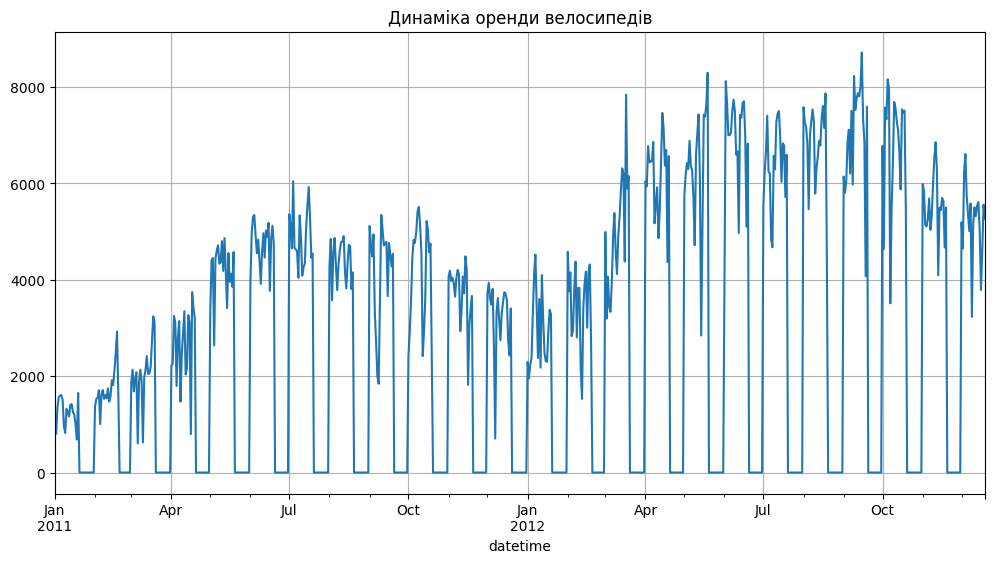

In [8]:
daily.plot(kind='line', figsize=(12,6),title='Динаміка оренди велосипедів', grid=True)
plt.show()

In [9]:
df.index.day.unique()

Index([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dtype='int32', name='datetime')

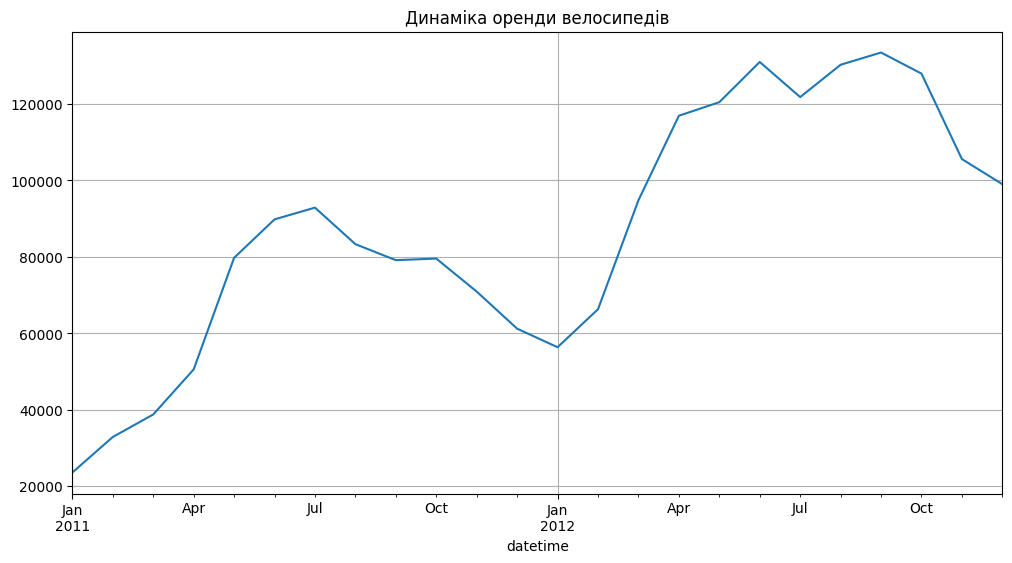

In [10]:
daily = df.resample('ME')['count'].sum()
daily.plot(kind='line', figsize=(12,6),title='Динаміка оренди велосипедів', grid=True)
plt.show()

1. Чому графік має «заломи» і як їх прибрати.
У даних присутні лише дні з 1 по 19 число кожного місяця - решту днів (20-31) у датасеті приховано. Метод resample('D') створює рядок для кожного календарного дня, а для відсутніх днів підставляє 0. Через це лінія щомісяця падає до нуля. Щоб прибрати заломи, я згрупував дані не поденно, а помісячно (resample('ME')) - тоді відсутні дні «розчиняються» всередині місяця, і лінія стає плавною.

2. Загальні тенденції.
Спостерігається чіткий зростаючий тренд рік до року: у січні 2011 місячна оренда становила близько 24 000, а до осені 2012 сягнула майже 130 000. Тобто популярність сервісу за два роки суттєво зросла,

3. Сезонні коливання.
Так, сезонність яскраво виражена й повторюється щороку: оренда низька взимку (січень), зростає навесні, сягає піку влітку (червень-липень), а потім знижується до зими.

4. Аномалії.
Після групування по місяцях явних аномальних викидів немає — крива плавна. Найнижчі значення припадають на зимові місяці (січень), найвищі - на літні (липень). Це не аномалії, а прояв сезонності.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [11]:
season1 = df.groupby('season')['count'].mean()
season1

,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


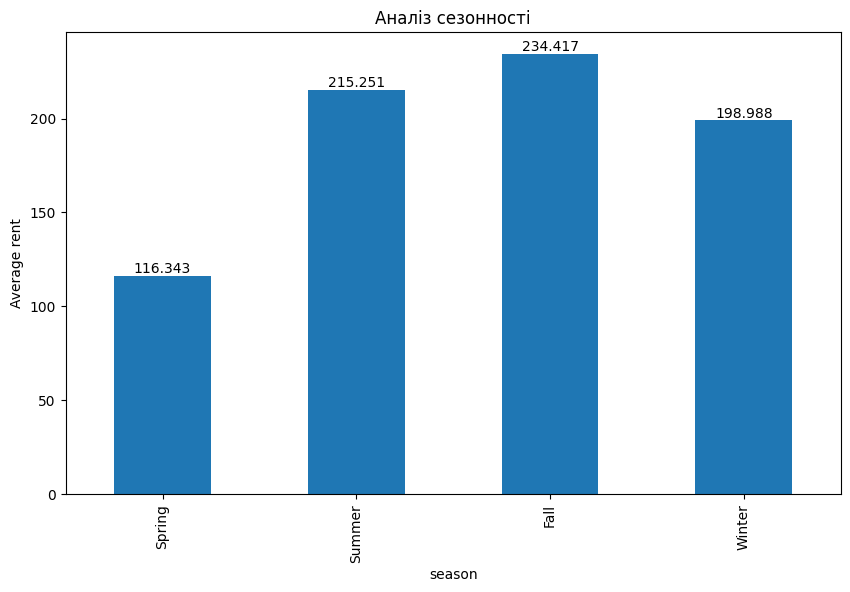

In [12]:
season1 = season1.rename({1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'})
ax = season1.plot.bar(
    figsize = (10,6),
    ylabel = ('Average rent')
)
ax.bar_label(ax.containers[0])
plt.title('Аналіз сезонності')
plt.show()

Сезонність напряму пов'язана з погодними умовами. Оренда найвища восени та влітку, це найкомфортніші сезони для їзди на велосипеді. Осінь навіть трохи випереджає літо: можливо, влітку занадто спекотно, а осіння прохолода комфортніша для поїздок.

Водночас є неочікуваний момент: середня оренда взимку (199) вища, ніж навесні (116), хоча логічно було б навпаки. Ймовірне пояснення, дані починаються з січня 2011 року, коли сервіс лише запускався, і кількість оренд була дуже низькою. Це «затягнуло» середнє по весні вниз. Тобто низька весна пояснюється не погодою, а стартовим періодом бізнесу. Щоб перевірити цю гіпотезу, варто окремо порівняти весну за 2011 і 2012 роки.

In [13]:
print('Оренда між найпопулярнішим та найменш популярним кварталами виідризняється в', round(season1.max() / season1.min(),2))


Оренда між найпопулярнішим та найменш популярним кварталами виідризняється в 2.01


## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [14]:
monthly = df.groupby('month')['count'].mean()
monthly


,count
month,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


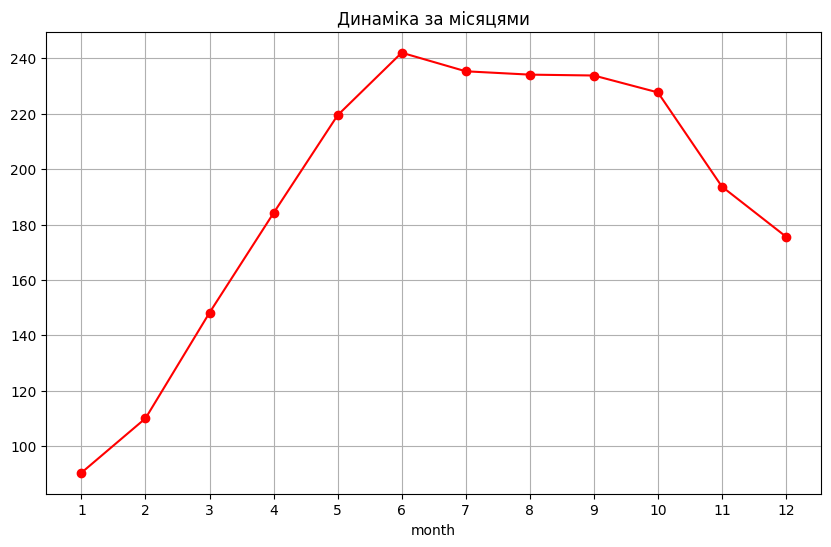

In [15]:
monthly.plot(
    kind='line',
    marker='o',
    figsize=(10,6),
    grid=True,
    color='red'
)
plt.title('Динаміка за місяцями')
plt.xticks(range(1,13))
plt.show()

Пік оренди припадає на червень-липень (місяці 6-7, близько 242), спад  на січень (місяць 1, близько 90). Активний період триває з травня по жовтень.
Загалом закономірність збігається з попереднім завданням: тепла пора року дає високу оренду, холодна - низьку. Проте помісячний графік детальніший, він показує, що пік припадає саме на літо (червень-липень), тоді як групування по сезонах трохи згладжувало картину. Тобто напрямок однаковий, але помісячна деталізація точніша.
Клімат прямо впливає на оренду: що тепліше й комфортніше на вулиці, то більше людей їздить на велосипеді. Тому в теплі місяці (травень-жовтень) оренда висока, а в холодні (листопад-лютий) - низька. Погода є одним із головних факторів попиту на цей сервіс.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

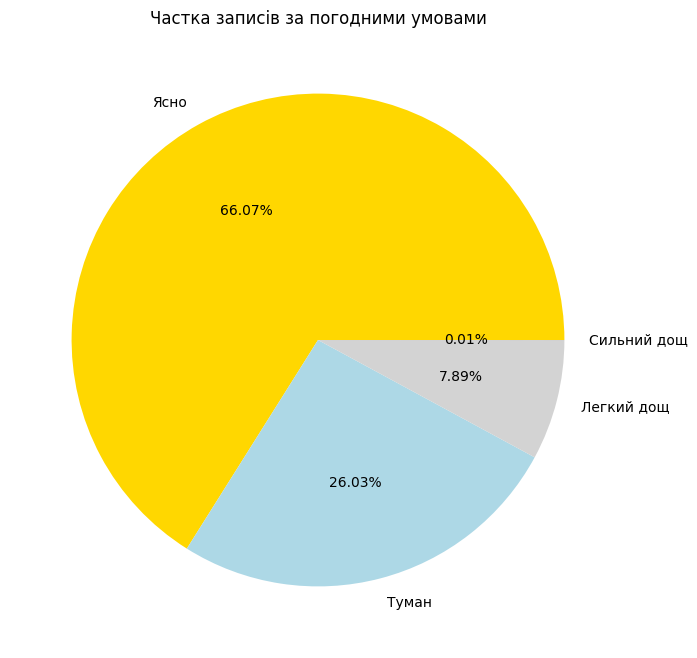

In [18]:
weather_counts = df['weather'].value_counts()
weather_counts

,count
weather,
1,7192
2,2834
3,859
4,1


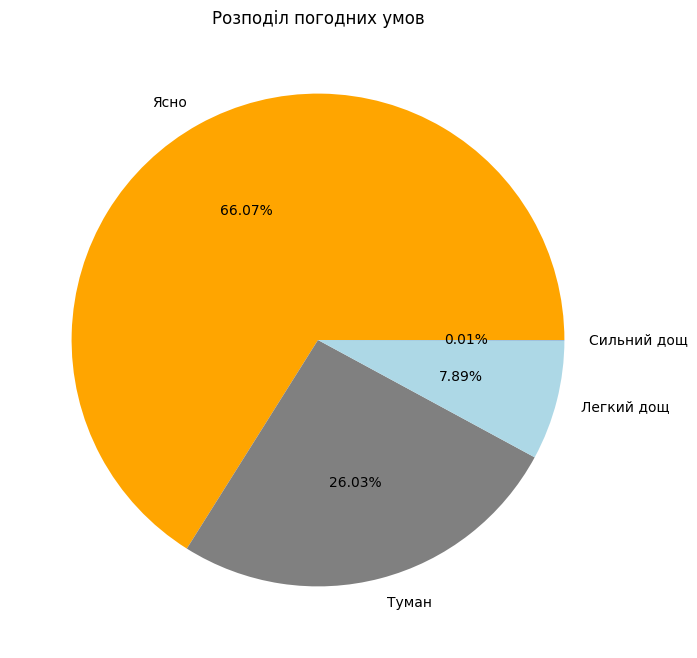

In [26]:
weather_counts = weather_counts.rename({1:'Ясно', 2:'Туман', 3:'Легкий дощ',4:'Сильний дощ'})
weather_counts.plot(
    title='Розподіл погодних умов',
    kind='pie',
    figsize=(8,8),
    autopct='%1.2f%%',
    colors=['orange','grey','lightblue','darkblue']

)
plt.ylabel('')
plt.show()

У датасеті переважає ясна погода — 66.07% записів. Далі йдуть туман (26.03%) та легкий дощ (7.89%).
Дні із сильним дощем практично відсутні — їхня частка становить лише 0.01% (по суті одна-дві записи з 10886). Це рідкісне явище в даних.
Логічно припустити, що погода впливає на попит: у ясну погоду люди охочіше беруть велосипед, а туман чи дощ знижують попит. Проте варто зазначити: ця діаграма показує лише частоту кожної погоди, а не рівень оренди. Щоб підтвердити вплив погоди на попит, потрібно порівняти середню кількість оренд за типами погоди (це зробимо в наступному завданні через box plot).

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

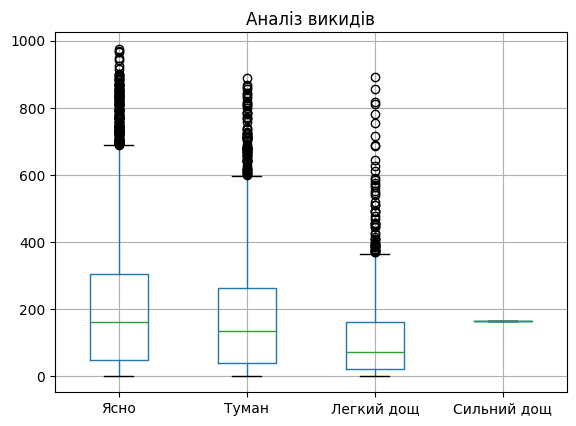

In [38]:
df.boxplot(
    column='count',
    by='weather'
)
plt.xlabel('')
plt.suptitle('')
plt.title('Аналіз викидів')
plt.xticks([1,2,3,4],['Ясно','Туман','Легкий дощ','Сильний дощ'])
plt.show()

Найбільший розкид у кількості оренди - за ясної погоди (weather=1): ящик найвищий, а викиди сягають майже 1000. Це логічно - у гарну погоду попит коливається від низького до дуже високого.
Викиди (outliers) є за погоди 1 (ясно), 2 (туман) і 3 (легкий дощ) - це точки над «вусами», тобто години з аномально високою орендою. Найбільше їх за ясної погоди.
Найвища медіана - за ясної погоди (близько 160), і вона знижується з погіршенням погоди (легкий дощ - близько 70). Формально найвища лінія у погоди 4 (сильний дощ), але там лише один запис, тому робити висновок за ним не можна -
вибірка занадто мала.

## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

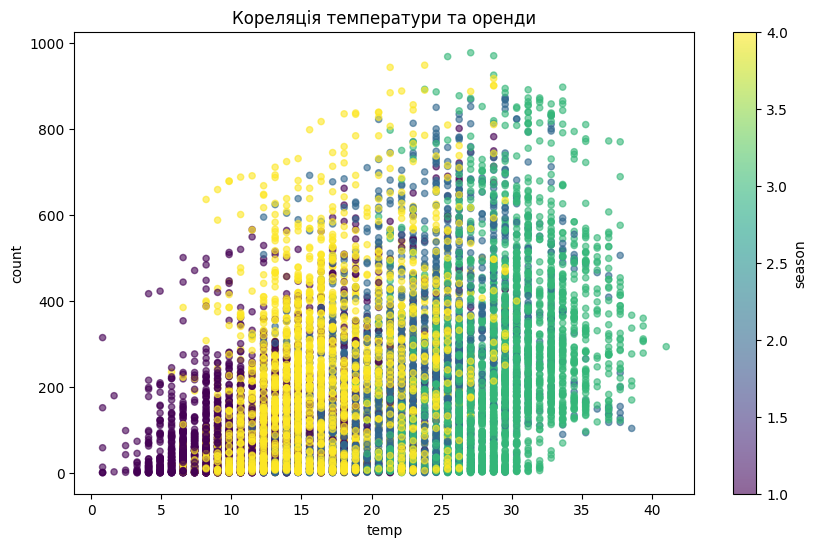

In [46]:
df.plot(
    kind='scatter',
    x='temp',
    y='count',
    c='season',
    alpha=(0.6),
    figsize=(10,6),
    colormap=('viridis')

)
plt.title('Кореляція температури та оренди')
plt.show()

Так, між температурою та кількістю оренди є позитивна кореляція. На графіку видно: за низької температури (0-10) точки скупчені внизу - оренда невелика; зі зростанням температури хмара точок піднімається вгору - оренда збільшується. Тобто чим тепліше, тим більше людей орендують велосипеди.

Водночас зв'язок не є строго лінійним: за дуже високої температури (35-40) оренда вже не зростає, а тримається на рівні або трохи знижується - ймовірно, у сильну спеку їздити некомфортно.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

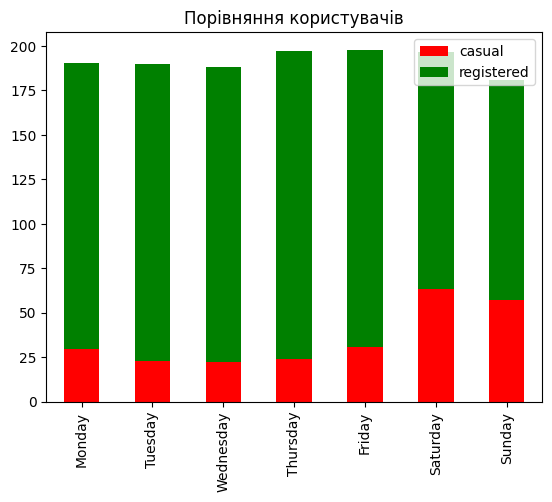

In [51]:
weekly = df.groupby('weekday')[['casual','registered']].mean()
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly = weekly.reindex(order)
weekly.plot(
    kind='bar',
    stacked=True,
    color=['red','green']

)
plt.title('Порівняння користувачів')
plt.xlabel('')
plt.show()

1. Зареєстровані користувачі (registered) орендують більше у будні дні (понеділок-п'ятниця). У вихідні їхня активність трохи знижується.

2.Два типи користувачів поводяться дзеркально:

Зареєстровані — це, ймовірно, постійні користувачі з підпискою, які використовують велосипед для регулярних поїздок: на роботу, у справах, для пересування містом. Тому їхня активність висока саме в будні.
Випадкові (casual) — це разові користувачі: туристи, прогулянки, відпочинок. Їхня активність різко зростає у вихідні (субота-неділя), коли люди мають вільний час для дозвілля.

Тобто в будні переважає «робочий» патерн (постійні клієнти їдуть у справах), а у вихідні — «дозвіллєвий» (випадкові користувачі катаються для відпочинку).